<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 155.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 188.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 156.5 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


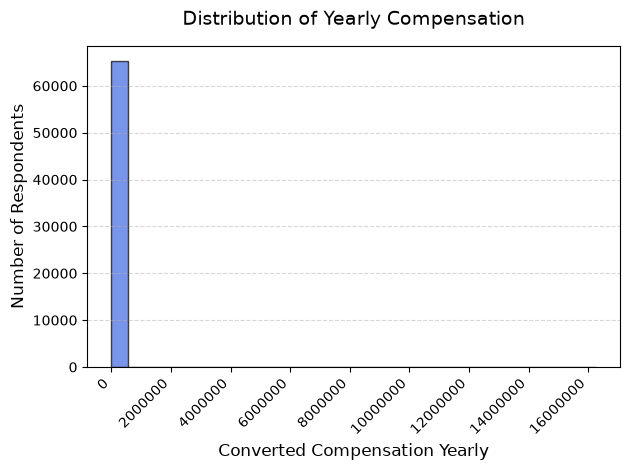

In [8]:
## Write your code here
df = df.copy()
median = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median)
df["ConvertedCompYearly"].plot(
    kind="hist", bins=30, color="royalblue", edgecolor="black", alpha=0.7
)

plt.title("Distribution of Yearly Compensation", fontsize=14, pad=15)
plt.xlabel("Converted Compensation Yearly", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="both")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [10]:
## Write your code here
full_time_df = df[df["Employment"] == "Employed, full-time"]
full_time_median = full_time_df["ConvertedCompYearly"].median()

print("FULL-TIME COMPENSATION ANALYSIS")
print("=" * 35)
print(f"Total Full-Time Respondents:  {len(full_time_df):,}")
print(f"Median Yearly Compensation:   ${int(full_time_median):,}")


FULL-TIME COMPENSATION ANALYSIS
Total Full-Time Respondents:  39,041
Median Yearly Compensation:   $65,000


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [12]:
## Write your code here
df = df.copy()
df.dropna(subset=['Country'], axis = 0, inplace = True)
df['Country'].isna().sum()

np.int64(0)

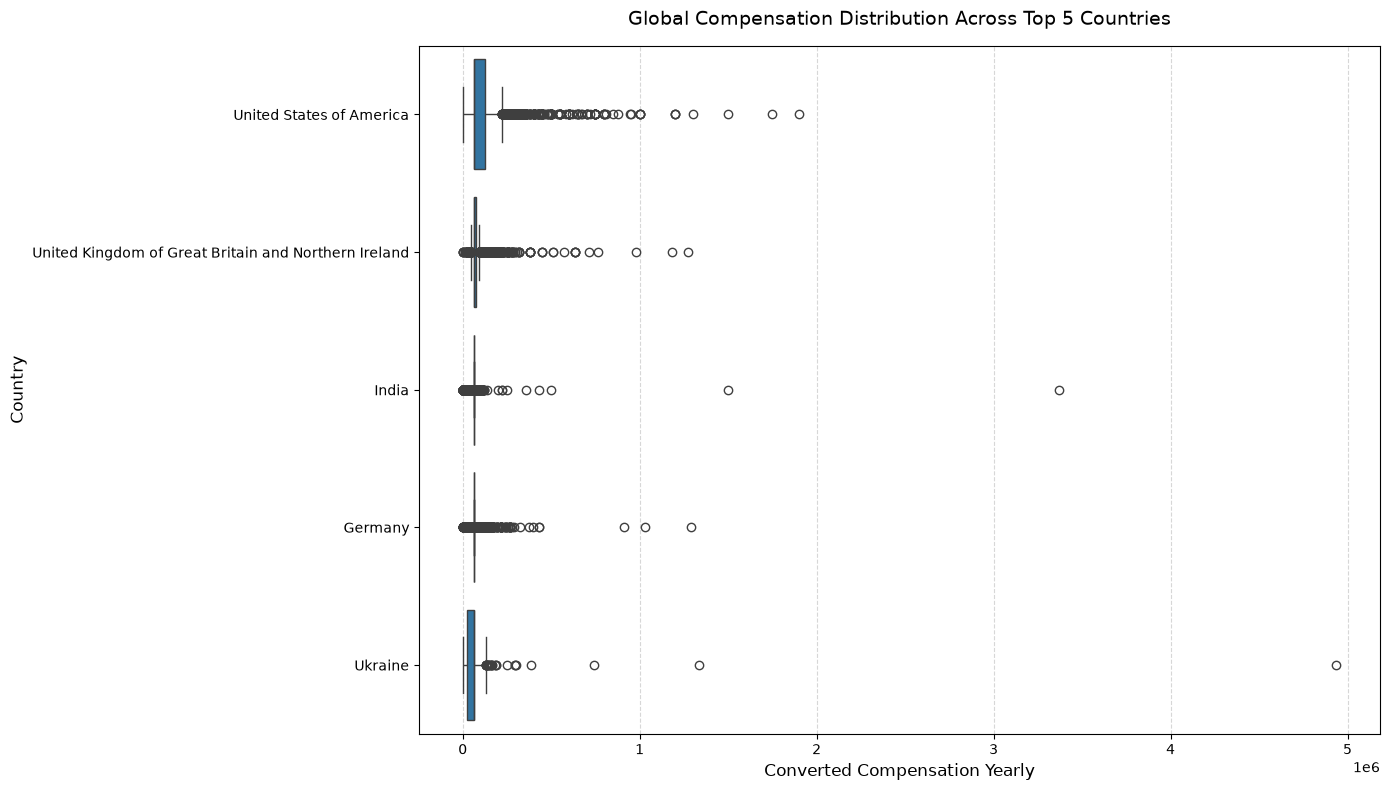

In [16]:
counts = df["Country"].value_counts()
top_countries = counts.sort_values(ascending=False).head(5).index
df_top_countries = df[df["Country"].isin(top_countries)]
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_top_countries,
    x="ConvertedCompYearly",
    y="Country",
    orient="h",  # Horizontal orientation for long country names
)
plt.title(
    "Global Compensation Distribution Across Top 5 Countries",
    fontsize=14,
    pad=15,
)
plt.xlabel("Converted Compensation Yearly", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [17]:
## Write your code here
df_working = df.dropna(subset=["ConvertedCompYearly"]).copy()

q1 = df_working["ConvertedCompYearly"].quantile(0.25)
q3 = df_working["ConvertedCompYearly"].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - (1.5 * IQR)
upper_bound = q3 + (1.5 * IQR)

#Create a new DataFrame excluding the outliers
df_cleaned = df_working[
    (df_working["ConvertedCompYearly"] >= lower_bound)
    & (df_working["ConvertedCompYearly"] <= upper_bound)
].copy()

#Validate the sizes of the DataFrames
original_total = len(df)
dropped_na_total = len(df_working)
cleaned_total = len(df_cleaned)
outliers_removed = dropped_na_total - cleaned_total

print("DATA VALIDATION REPORT")
print("=" * 30)
print(f"Original Rows (with NaNs):     {original_total:,}")
print(f"Rows after dropping NaNs:      {dropped_na_total:,}")
print(f"Cleaned Rows (No Outliers):    {cleaned_total:,}")
print("-" * 30)
print(f"Total Outlier Rows Removed:    {outliers_removed:,}")

DATA VALIDATION REPORT
Original Rows (with NaNs):     58,930
Rows after dropping NaNs:      58,930
Cleaned Rows (No Outliers):    35,532
------------------------------
Total Outlier Rows Removed:    23,398


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [20]:
correlate = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']]
correlation_matrix = correlate.corr()
correlation_matrix

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.106432,0.013988
WorkExp,0.106432,1.000000,-0.026490
JobSatPoints_1,0.013988,-0.026490,1.000000


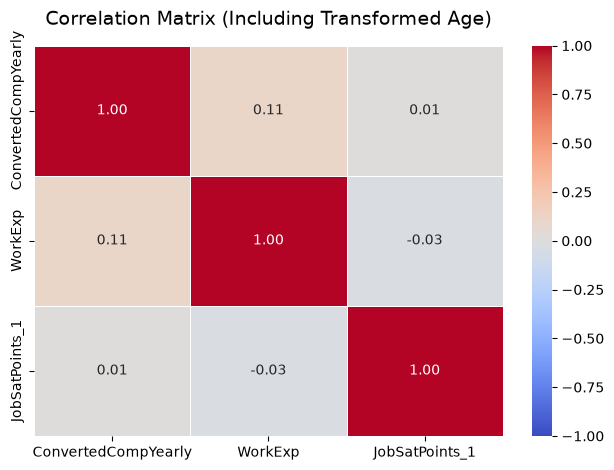

In [21]:
## Write your code here

sns.heatmap(
    correlation_matrix,
    annot=True,  # Displays the correlation numbers inside the boxes
    cmap="coolwarm",  # Red for positive correlation, Blue for negative
    fmt=".2f",  # Limits decimal points to 2 digits
    linewidths=0.5,  # Adds a clean white border between squares
    vmin=-1,  # Sets the minimum scale bound
    vmax=1,  # Sets the maximum scale bound
)

plt.title("Correlation Matrix (Including Transformed Age)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


NUMERIC CORRELATION STRENGTHS
1. Compensation vs Work Experience (r): 0.1064
2. Compensation vs Job Satisfaction (r): 0.0140


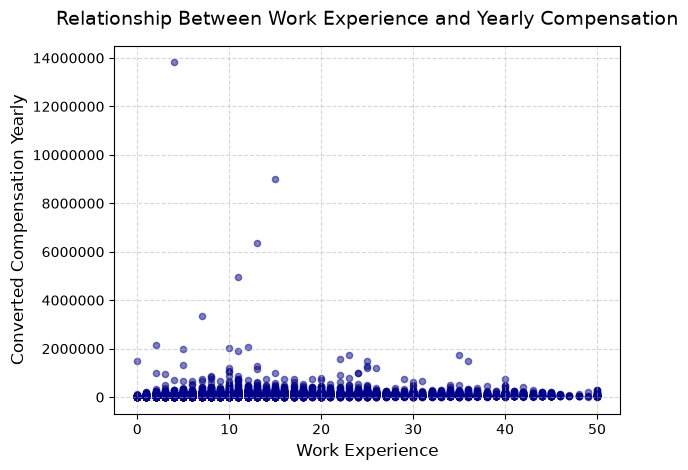

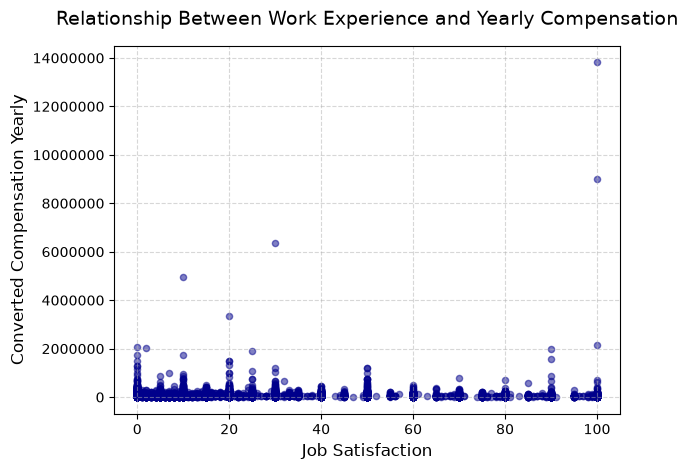

In [28]:
## Write your code here
correlate1 = df[['ConvertedCompYearly', 'WorkExp']]
correlation1_matrix = correlate1.corr()

correlate2 = df[['ConvertedCompYearly','JobSatPoints_1']]
correlation2_matrix = correlate2.corr()

print("NUMERIC CORRELATION STRENGTHS")
print("=" * 45)

# Extract the specific correlation value between the two columns
r_work_exp = correlation1_matrix.loc["ConvertedCompYearly", "WorkExp"]
print(f"1. Compensation vs Work Experience (r): {r_work_exp:.4f}")

# Extract the specific correlation value for job satisfaction
r_job_sat = correlation2_matrix.loc["ConvertedCompYearly", "JobSatPoints_1"]
print(f"2. Compensation vs Job Satisfaction (r): {r_job_sat:.4f}")
print("=" * 45)

#First plot
correlate1.plot(
    kind="scatter",
    x="WorkExp",  # Horizontal axis
    y="ConvertedCompYearly",  # Vertical axis
    alpha=0.5,  # Makes dots translucent to see where data clusters
    color="darkblue",  # Color of the dots
)

plt.title(
    "Relationship Between Work Experience and Yearly Compensation",
    fontsize=14,
    pad=15,
)
plt.xlabel("Work Experience", fontsize=12)
plt.ylabel("Converted Compensation Yearly", fontsize=12)

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#Second plot
correlate2.plot(
    kind="scatter",
    x="JobSatPoints_1",  # Horizontal axis
    y="ConvertedCompYearly",  # Vertical axis
    alpha=0.5,  # Makes dots translucent to see where data clusters
    color="darkblue",  # Color of the dots
)

plt.title(
    "Relationship Between Work Experience and Yearly Compensation",
    fontsize=14,
    pad=15,
)
plt.xlabel("Job Satisfaction", fontsize=12)
plt.ylabel("Converted Compensation Yearly", fontsize=12)

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
